mu_test: -6276.0
mu_recovered: -6276.0
error: 0.0


/tmp/ipykernel_3025246/1462158258.py:58: RuntimeWarning: invalid value encountered in sqrt
  return (-b + np.sqrt(discriminant)) / (2*a)  # physical root


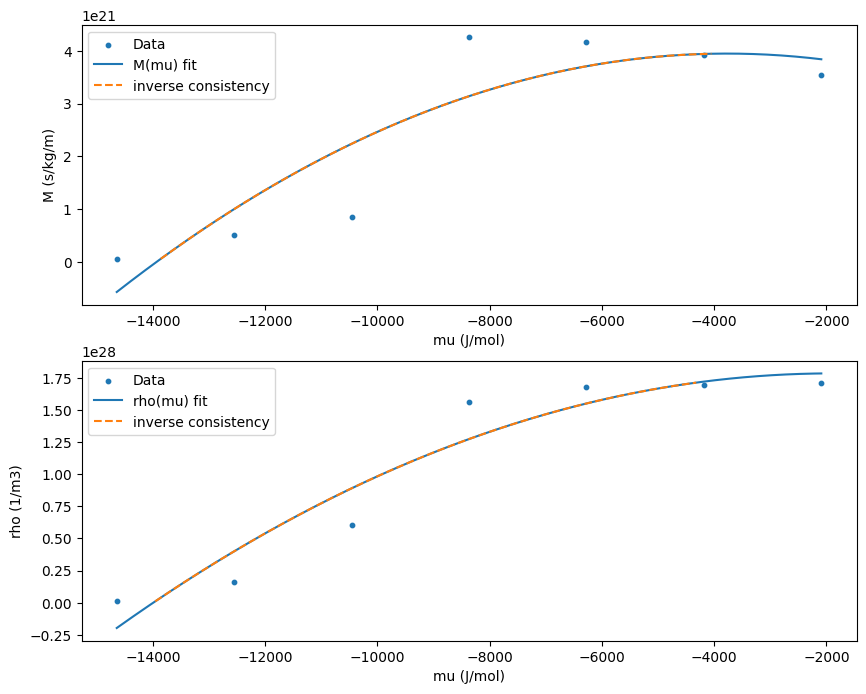

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Define some constants
volume = 4e-9 * 4e-9 * 2e-9 # m3
area = 4e-9 * 2e-9 # m2
m = 40e-3 # mass particle in kg/mol
Na = 6.022e23 # Avogadro
kcal_to_j = 4184.0 # Convert factor

degree = 2 # Degree for polynomial fit
# WARNING: the analytical inversion functions (invert_poly2, mu_from_rho_analytical)
# are hardcoded for degree=2 only. If degree is changed, these must be replaced
# by a numerical root-finding approach (e.g. scipy.optimize.brentq).

f0_real = 0.01 # force applied on each particle kcal/mol/A
f0_SI = f0_real * kcal_to_j * 1e10 / Na # N

# Load MD data

md_data = np.loadtxt("MD/number_and_v_vs_mu.dat")
mu_real, number, v_real = md_data.T # kcal/mol, 0, A/fs

# Quantities in SI units
mu_SI = mu_real * kcal_to_j
v_SI = v_real * 1e-10/1e-15
rho_SI = number/volume # m-3
total_force = rho_SI * f0_SI * volume # N
total_flux = rho_SI * v_SI * area # 1 / s
M_SI = total_flux / total_force # transport coefficient in 1/s/N = s / kg / m

# Fits
coeffs_M_vs_mu = np.polyfit(mu_SI, M_SI, degree)
coeffs_rho_vs_mu = np.polyfit(mu_SI, rho_SI, degree)

# Save fitting paramters
with open("M_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_M_vs_mu:
        f.write(f"{c}\n")

with open("rho_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_rho_vs_mu:
        f.write(f"{c}\n")

# To test the procedure
poly_K_vs_mu = np.poly1d(coeffs_M_vs_mu)
poly_rho_vs_mu = np.poly1d(coeffs_rho_vs_mu)

coeffs = coeffs_rho_vs_mu  # [a, b, c]
a, b, c = coeffs

# Analytical inverses using coefficients from rho_vs_mu and M_vs_mu
def invert_poly2(y, coeffs):
    a, b, c = coeffs
    discriminant = b**2 - 4*a*(c - y)
    return (-b + np.sqrt(discriminant)) / (2*a)  # physical root

mu_test = mu_SI[-3]
rho = poly_rho_vs_mu(mu_test)
mu_recovered = invert_poly2(rho, coeffs_rho_vs_mu)
print("mu_test:", mu_test)
print("mu_recovered:", mu_recovered)
print("error:", mu_recovered - mu_test)

# Grids
mu_grid  = np.linspace(min(mu_SI), max(mu_SI), 300)
M_grid   = np.linspace(min(M_SI),  max(M_SI),  300)
rho_grid = np.linspace(min(rho_SI), max(rho_SI), 300)

# Forward fits
M_fit   = poly_K_vs_mu(mu_grid)
rho_fit = poly_rho_vs_mu(mu_grid)

# M consistency (analytical inverse)
mu_from_M = invert_poly2(M_grid, coeffs_M_vs_mu)
M_back    = poly_K_vs_mu(mu_from_M)

# rho consistency (analytical inverse)
mu_from_rho = invert_poly2(rho_grid, coeffs_rho_vs_mu)
rho_back    = poly_rho_vs_mu(mu_from_rho)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.scatter(mu_SI, M_SI, s=10, label="Data")
plt.plot(mu_grid, M_fit, label="M(mu) fit")
plt.plot(mu_from_M, M_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("M (s/kg/m)")
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(mu_SI, rho_SI, s=10, label="Data")
plt.plot(mu_grid, rho_fit, label="rho(mu) fit")
plt.plot(mu_from_rho, rho_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("rho (1/m3)")
plt.legend()